In [ ]:
'''
mac scgpt环境

1. 计算q_bio
2. 计算q_score

最终存储：20260114_fetal_B_celltype_merged-BCR_scVI_v2_qbcr.h5ad
'''

In [1]:
import scanpy as sc
fdir_file = './data/'
adata = sc.read_h5ad(fdir_file + 'Bcells_merged_BCR_palantir_pseudotime_v2.h5ad') # data_v2:29818 cells
adata

/opt/anaconda3/envs/scgpt/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


AnnData object with n_obs × n_vars = 29818 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype', 'filter_rna', 'has_contig', 'filter_contig_quality', 'filter_contig_VDJ', 'filter_contig_VJ', 'contig_QC_pass', 'filter_contig', 'clone_id', 'clone_id_by_size', 'sample_id', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_genotyped_VDJ', 'v_call_genotyped_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'duplicate_count_VDJ', 'duplicate_count_VJ', 'duplicate_count_VDJ_1', 'duplicate_count_VJ_1', 'duplicate_count_VDJ_2', 'duplicate_count_VDJ_3', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_status', 'locus_status_summary', 'productive', 'productive_summary', 'isotype', 'isotype_summary', 'vdj_status', 'vdj_status_summary', 'constant_status_s

(29818, 94)
             count  size      mean  median
celltype                                  
PRO_B         2771  2771  0.000475     0.0
PRE_PRO_B      967   967  0.000599     0.0
LATE_PRO_B    2887  2887  0.000759     0.0
PLASMA_B        25    25  0.001354     0.0
B1            2897  2897  0.002300     0.0
SMALL_PRE_B   4642  4642  0.002344     0.0
LARGE_PRE_B   4702  4702  0.002386     0.0
MATURE_B      8901  8901  0.002692     0.0
CYCLING_B      920   920  0.002770     0.0
IMMATURE_B    1106  1106  0.004256     0.0


/Users/zhangmeihan/anaconda_projects/BCR-aware-TI/btraj/downstream/plot.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_col)[time_col]


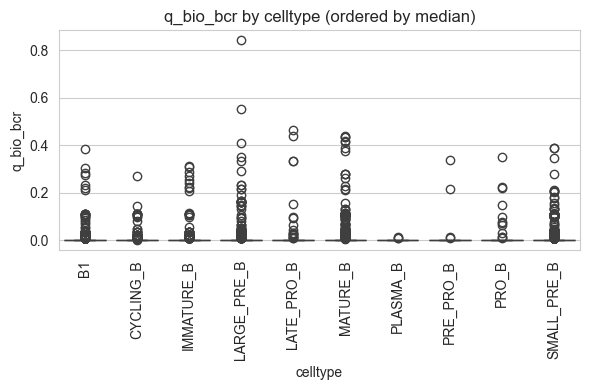

In [3]:
## 计算q_bio
from btraj.qscore.compute_q_score import *


weights = {"iso": 0.05, "shm": 0.90, "clonal": 0.05}

del adata.obs["isotype"]
adata.obs = adata.obs.rename(columns={'mu_freq':"SHM", 'ighc':"isotype"})

cell_bcr = adata.obs.copy()
print(cell_bcr.shape)
# cell_bcr = cell_bcr.loc[cell_bcr["SHM"].notna(), :].copy()
# print(cell_bcr.shape)

# 1) 拟合 SHM scaler：
shm_scaler = fit_shm_scaler_from_shm(cell_bcr, shm_col="SHM",q=(1, 100))
v_id_col = None

# 2) 拟合 clone scaler
clone_scaler = fit_clone_scaler(cell_bcr, clone_id_col="clone_id", q=95)

# 3) 计算 q_bio
cell_bcr["q_bio_bcr"] = cell_bcr.apply(
    lambda r: compute_q_bio_bcr_cell_v2(
        r,
        q_tech_bcr=r.get("q_tech_bcr"),
        igh_c_gene_col="isotype",
        shm_col="SHM",
        v_identity_col=v_id_col,
        shm_scaler=shm_scaler,
        clone_scaler=clone_scaler,
        weights=weights,
        tech_gate_power=1.0,   # 已经没压分，保持 1 即可
        coverage_power=0.0
    ),
    axis=1
)

adata.obs['q_bio_bcr'] = cell_bcr['q_bio_bcr'].reindex(adata.obs.index)

tmp = pd.DataFrame({
    "celltype": adata.obs["celltype"].astype(str).values,
    "q_bio_bcr": pd.to_numeric(adata.obs["q_bio_bcr"], errors="coerce").values
    })
print(tmp.groupby("celltype")["q_bio_bcr"].agg(["count","size","mean","median"]).sort_values("mean"))


from btraj.downstream.plot import boxplot_by_median
boxplot_by_median(adata, 'celltype','q_bio_bcr')

   alpha_from_qtech  beta_from_qbio  iqr_qtech  iqr_qbio  sat_qtech(>thr)  \
0          0.999954        0.000046   0.218968       0.0              0.0   

   sat_qbio(>thr)  effinfo_qtech  effinfo_qbio  
0             0.0       0.218968       0.00001  


/Users/zhangmeihan/anaconda_projects/BCR-aware-TI/btraj/downstream/plot.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_col)[time_col]


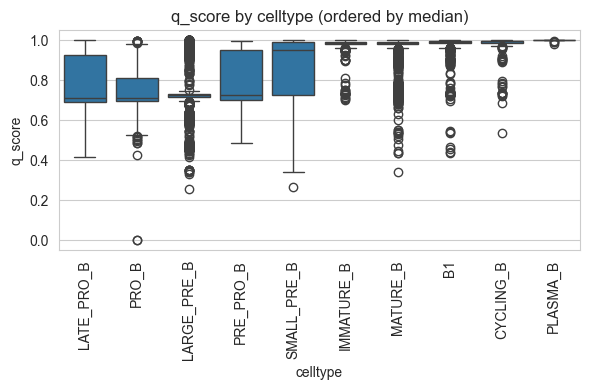

In [4]:
### 计算 q_score

compute_q_score_v2(
    adata,
    q_tech_key="q_tech_bcr",
    q_bio_key="q_bio_bcr",
    stretch_method="root_g2",
    # stretch_method=None,
    sat_thr=1,                 # 天花板阈值，可调 0.95-0.99
    eps=1e-5,
    out_q_score_key="q_score",      # 输出列名
    out_debug_key="q_score_debug"   # 调参表扔进 adata.uns
)
print(adata.uns["q_score_debug"])
boxplot_by_median(adata, 'celltype','q_score')

In [7]:
adata.obs['q_score'].value_counts()

q_score
1.000000    1154
0.730000    1000
0.991339     118
0.988747     117
0.992262     110
            ... 
0.740962       1
0.732705       1
0.735794       1
0.785110       1
0.939003       1
Name: count, Length: 3093, dtype: int64

In [10]:
adata.write(fdir_file + '20260114_fetal_B_celltype_merged-BCR_scVI_v2_qbcr.h5ad')